Using device: cuda
Loading spectral data...
Starting training...


/tmp/ipython-input-3574553365.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/100 - Train Loss: 0.100952 - Val Loss: 0.003017 - Time: 5.0s
Epoch 2/100 - Train Loss: 0.024746 - Val Loss: 0.002596 - Time: 4.7s
Epoch 3/100 - Train Loss: 0.018016 - Val Loss: 0.002047 - Time: 4.7s
Epoch 4/100 - Train Loss: 0.012905 - Val Loss: 0.001961 - Time: 4.8s
Epoch 5/100 - Train Loss: 0.009321 - Val Loss: 0.001869 - Time: 4.7s
Epoch 6/100 - Train Loss: 0.007022 - Val Loss: 0.001844 - Time: 5.2s
Epoch 7/100 - Train Loss: 0.005631 - Val Loss: 0.001821 - Time: 4.7s
Epoch 8/100 - Train Loss: 0.004765 - Val Loss: 0.001809 - Time: 4.6s
Epoch 9/100 - Train Loss: 0.004175 - Val Loss: 0.001805 - Time: 4.7s
Epoch 10/100 - Train Loss: 0.003735 - Val Loss: 0.001799 - Time: 4.6s
Epoch 11/100 - Train Loss: 0.003398 - Val Loss: 0.001798 - Time: 4.6s
Epoch 12/100 - Train Loss: 0.003136 - Val Loss: 0.001796 - Time: 4.7s
Epoch 13/100 - Train Loss: 0.002925 - Val Loss: 0.001795 - Time: 4.6s
Epoch 14/100 - Train Loss: 0.002749 - Val Loss: 0.001797 - Time: 4.6s
Epoch 15/100 - Train Loss: 0.

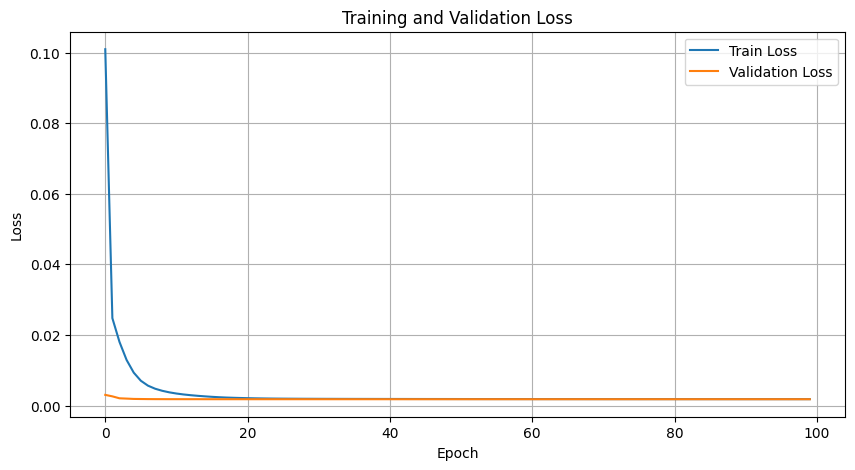

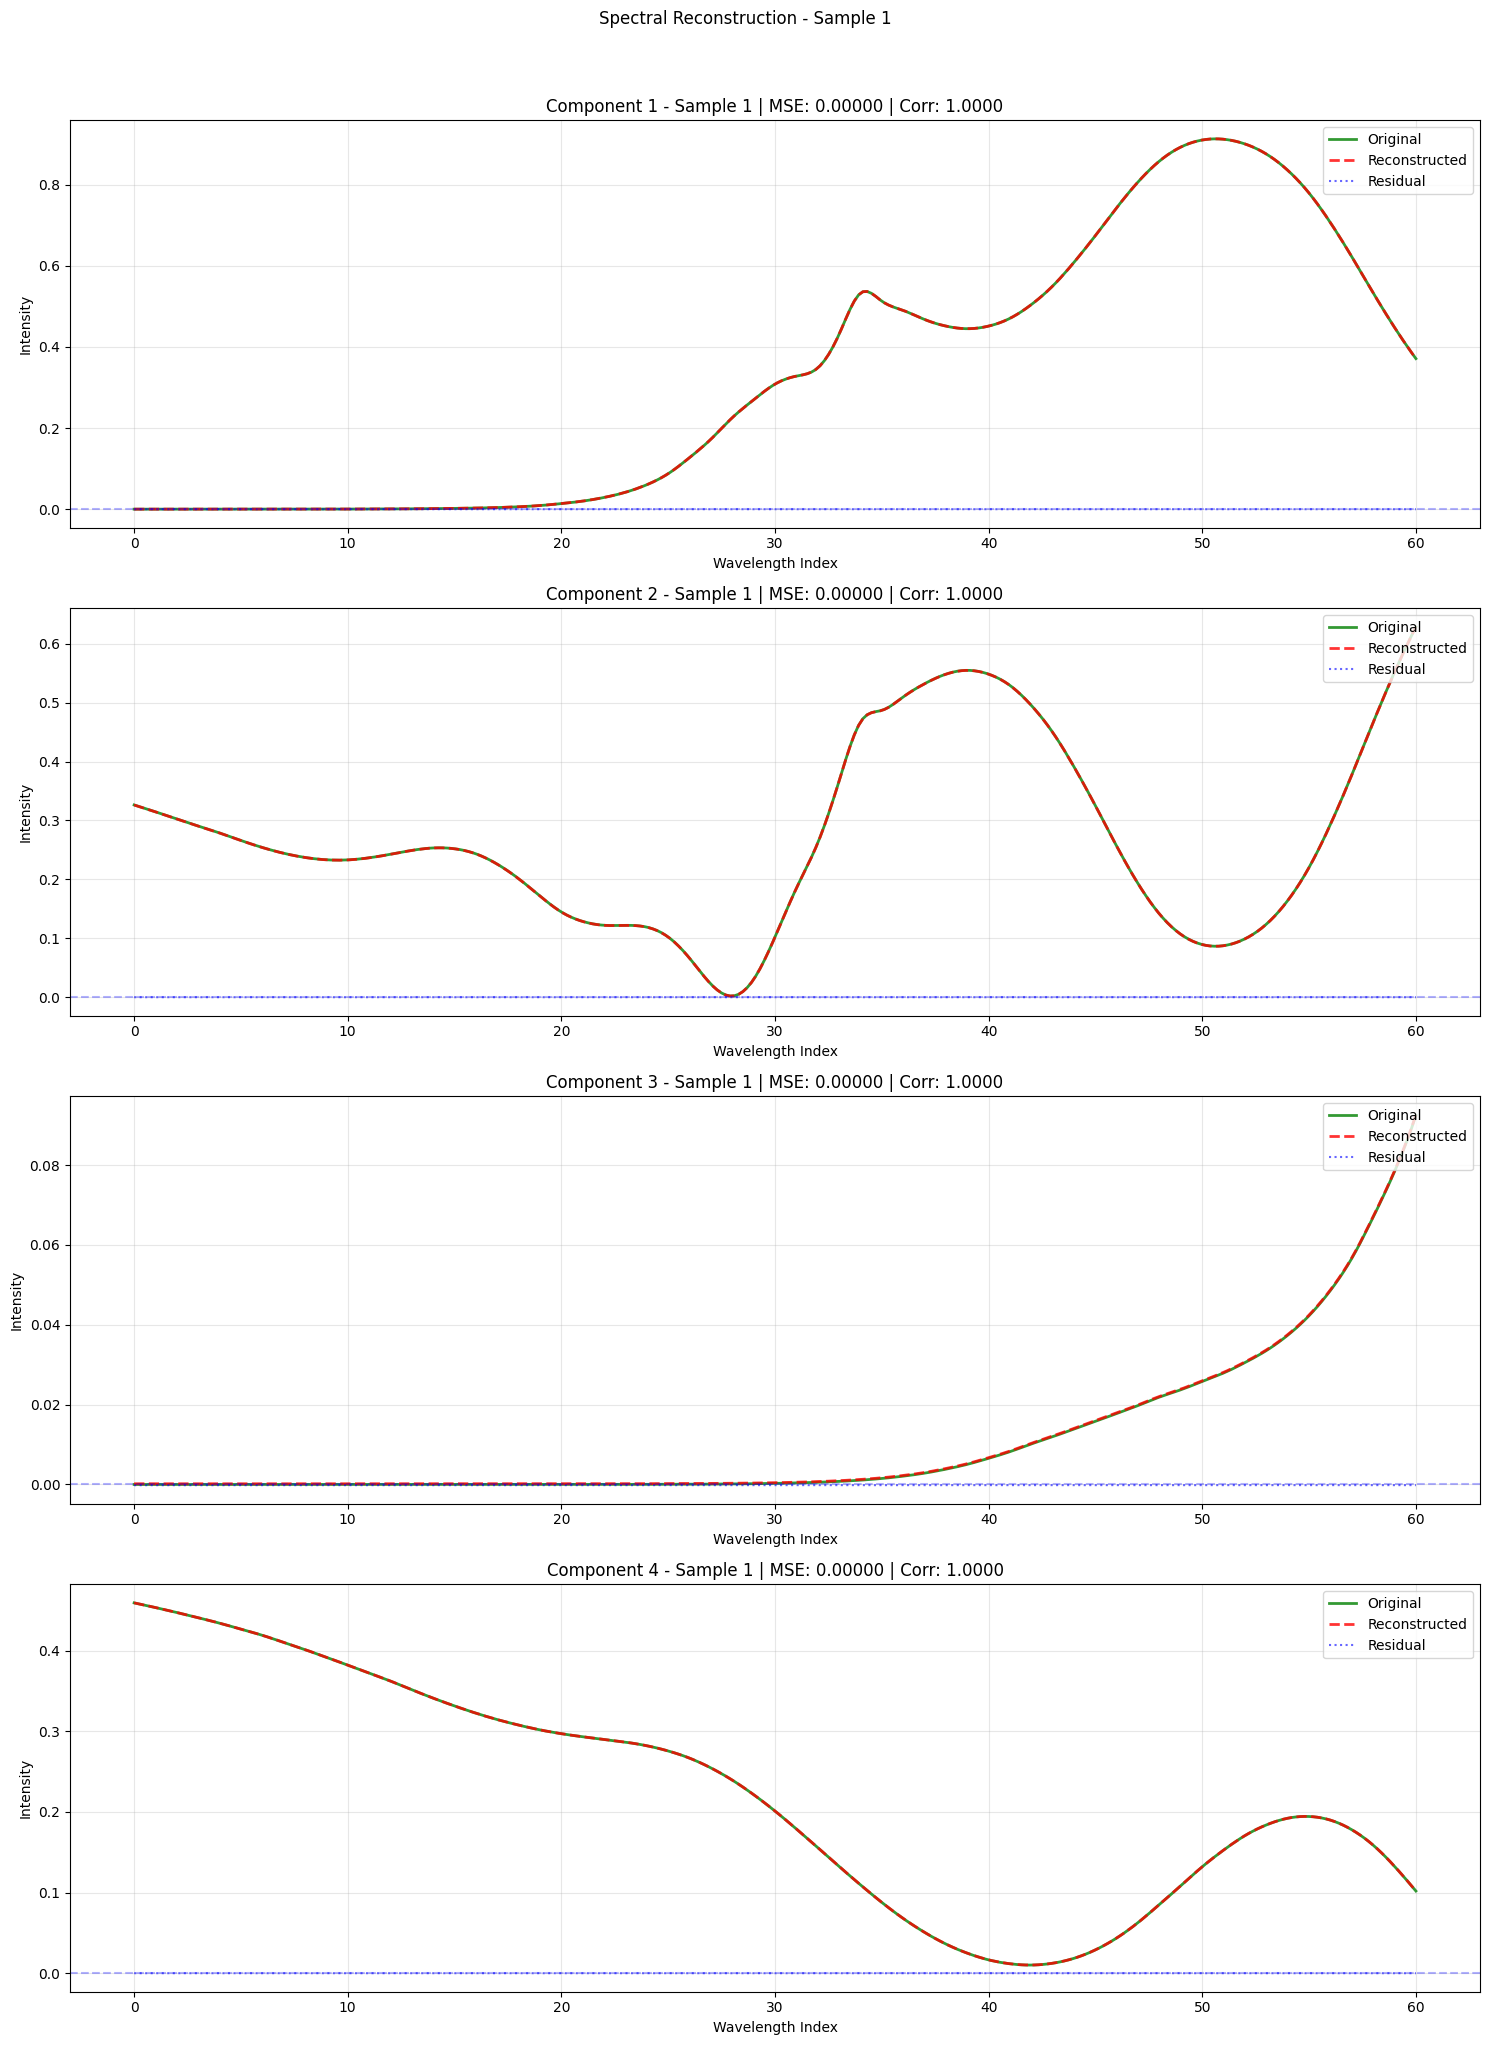

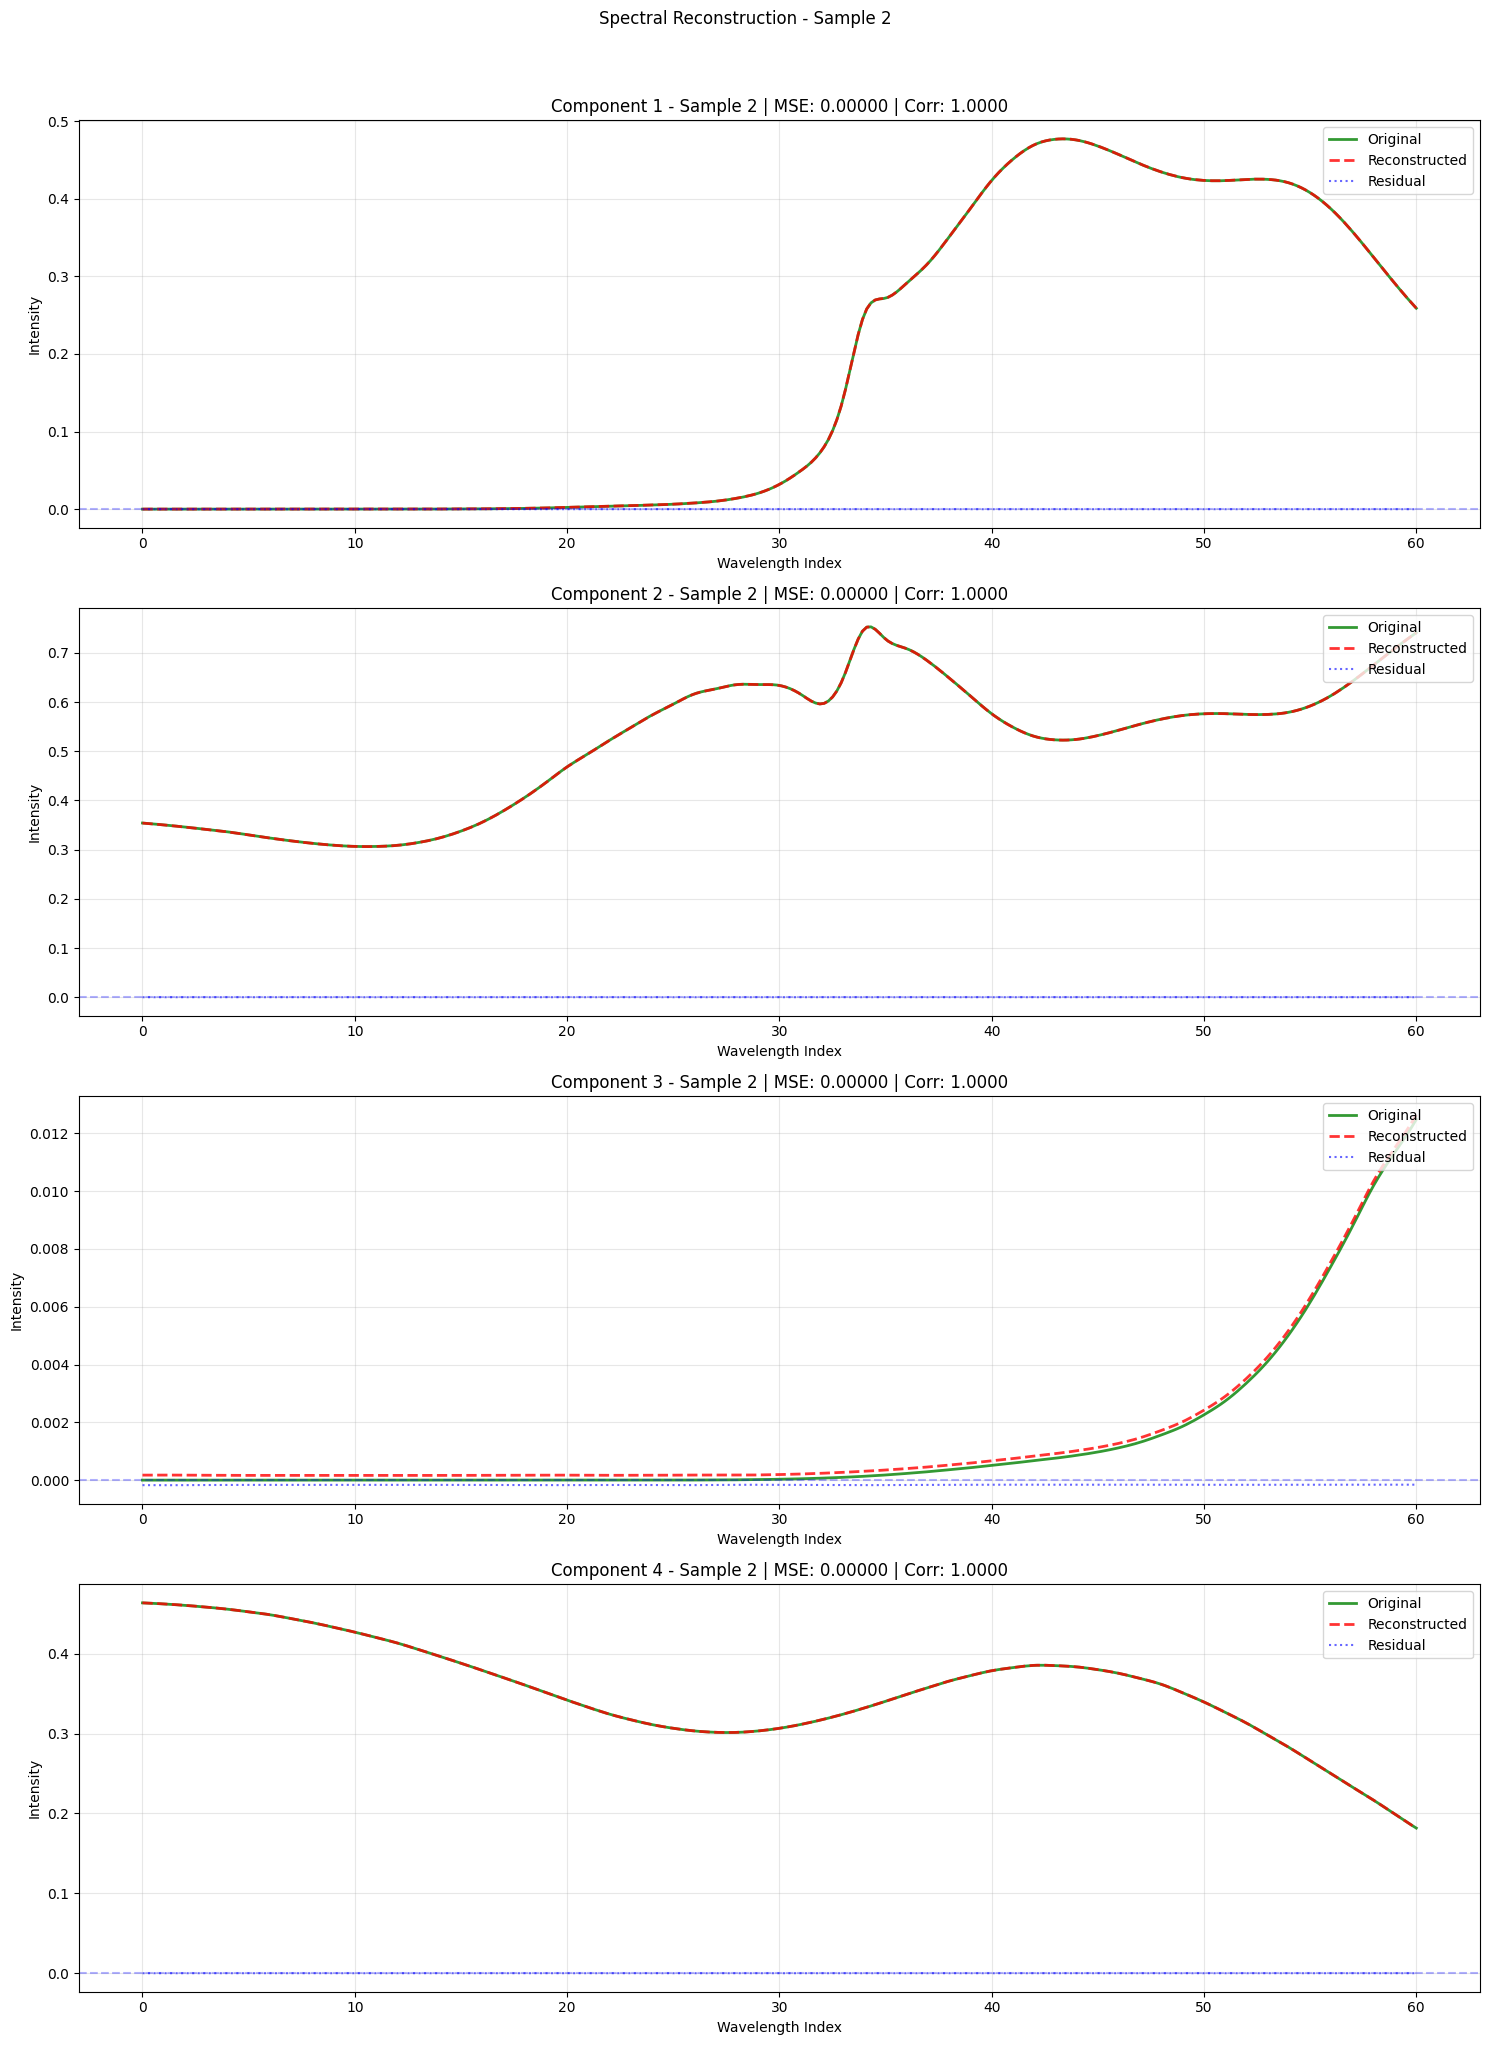

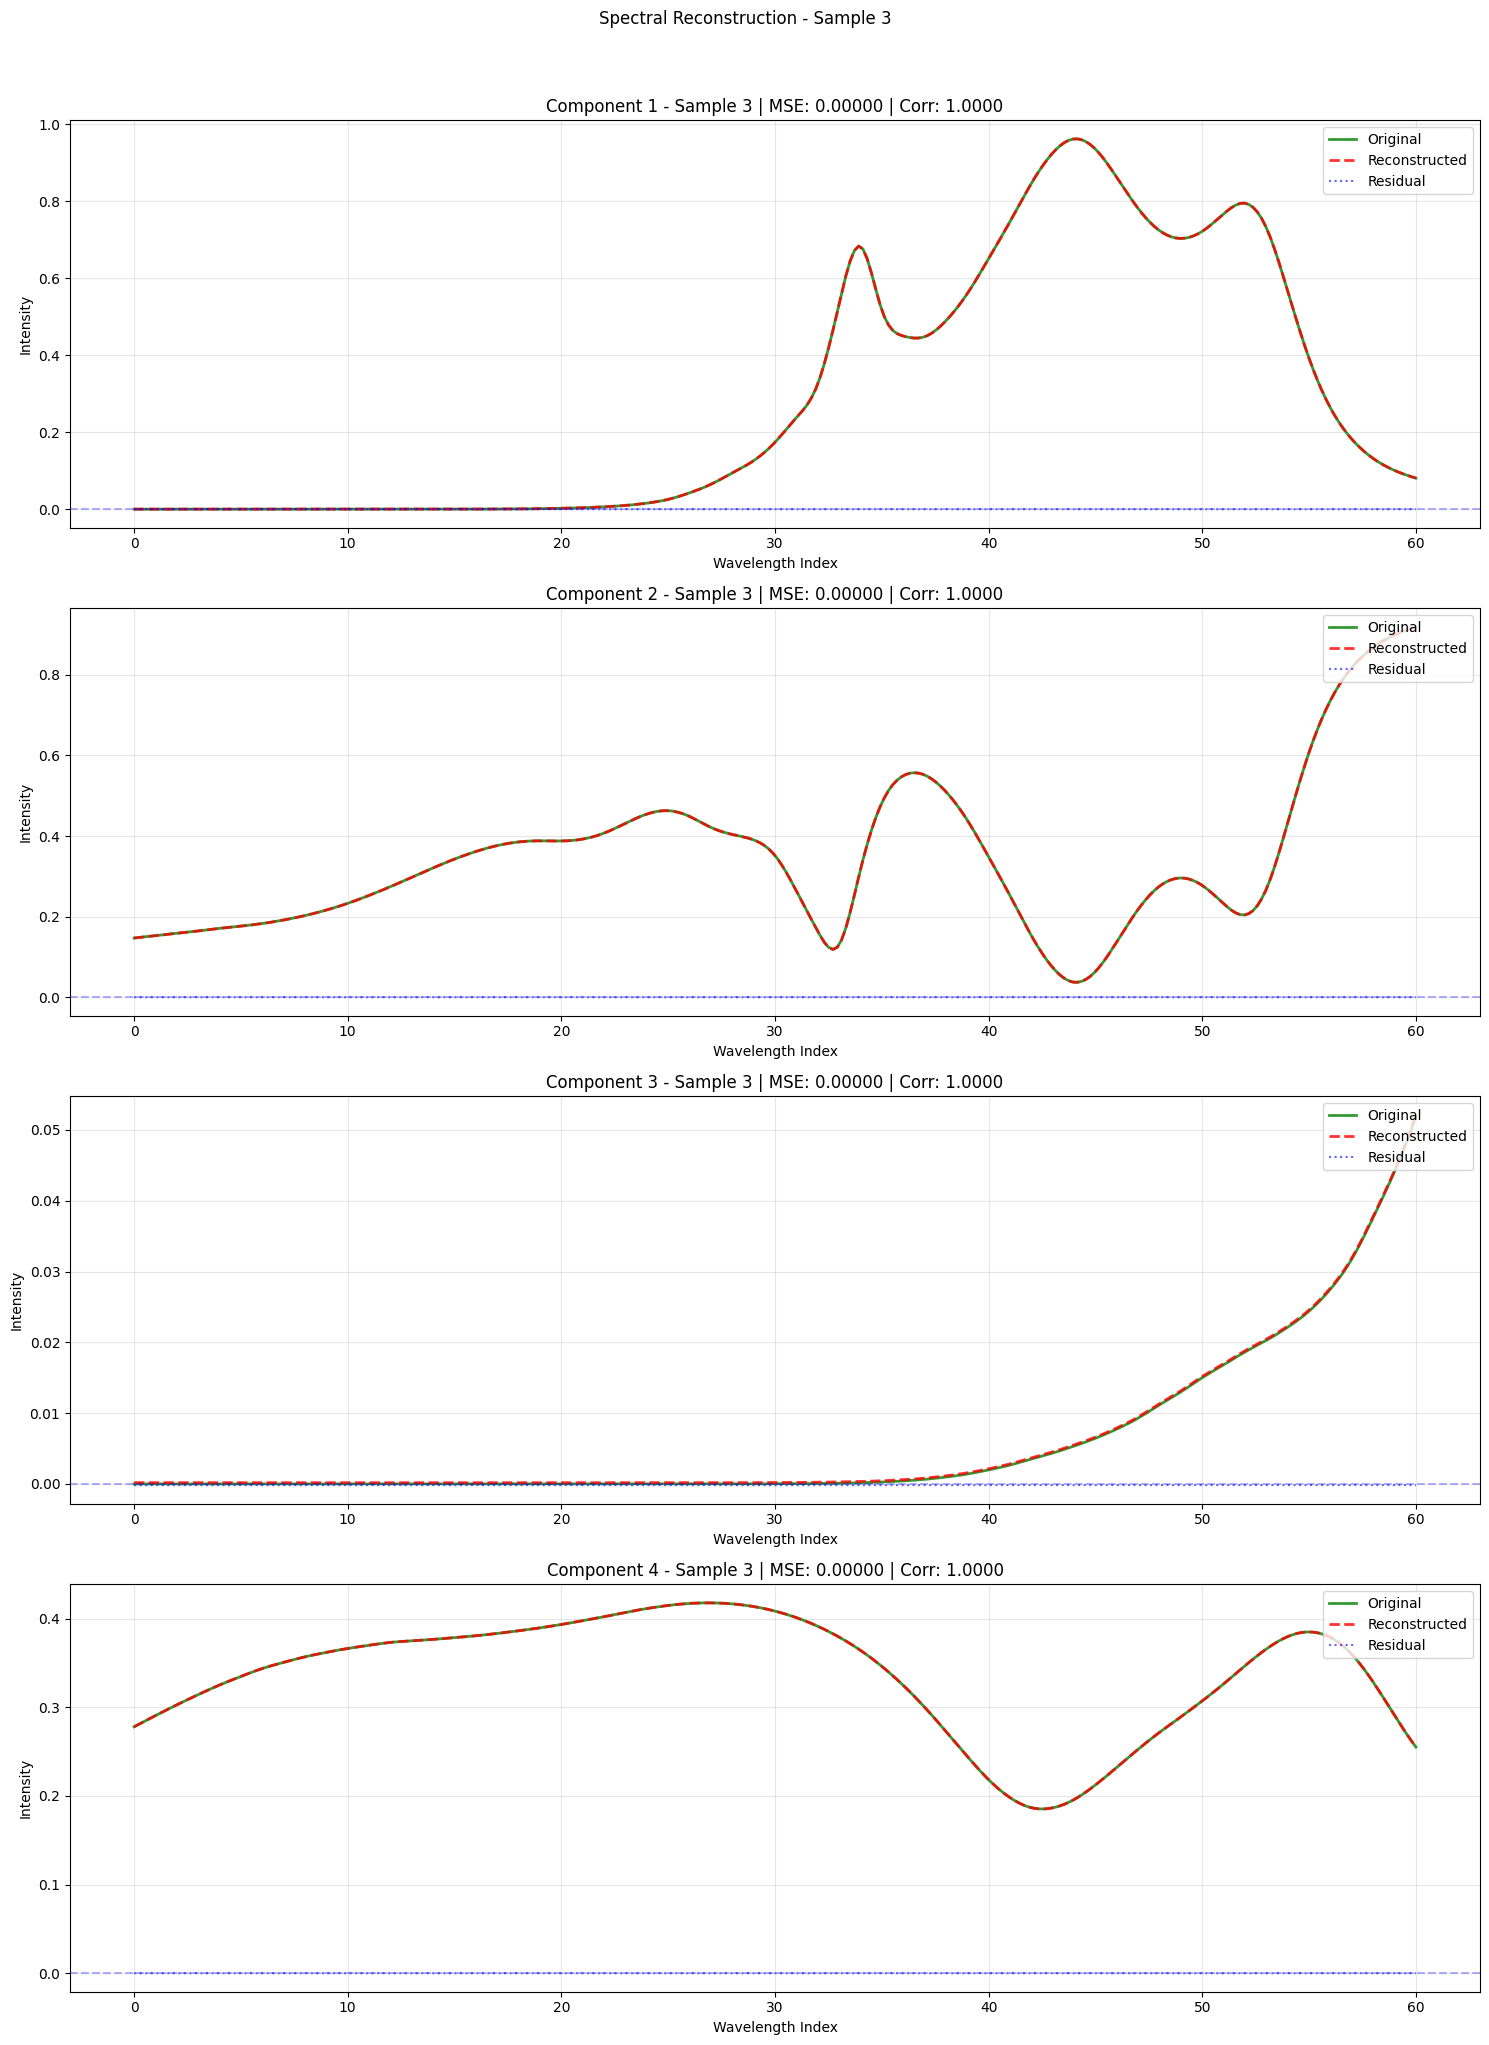

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


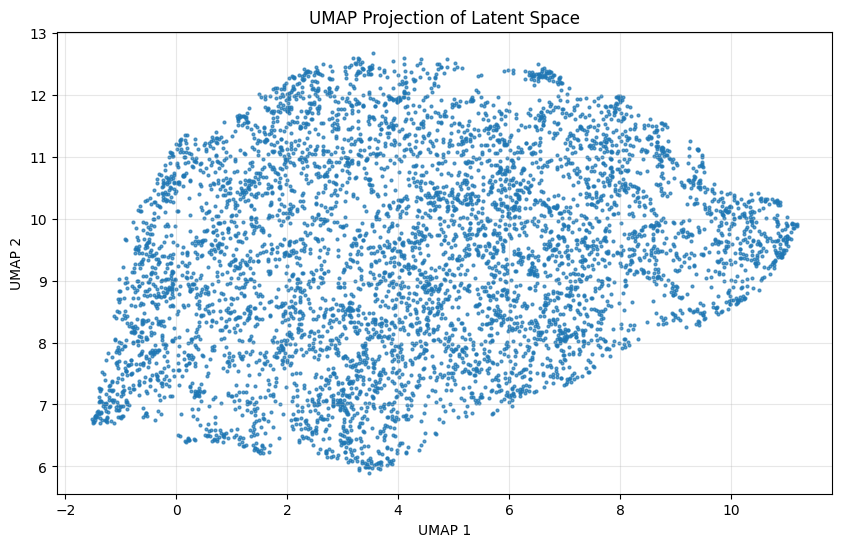

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from time import time
from scipy.interpolate import make_interp_spline
import umap

# ----- Device Setup -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
use_amp = device.type == 'cuda'
scaler_amp = torch.amp.GradScaler("cuda", enabled=use_amp)

# ----- Data Loading -----
print("Loading spectral data...")
Y_raw = np.loadtxt(r'/content/drive/MyDrive/Unsupervised/spectra_120k.dat').reshape(-1, 61, 4)[:30000]
Y_train_np, Y_test_np = train_test_split(Y_raw, test_size=0.2, random_state=42)
Y_train = torch.FloatTensor(Y_train_np)
Y_test = torch.FloatTensor(Y_test_np)

batch_size = 512
train_ds = TensorDataset(Y_train, Y_train)
test_ds = TensorDataset(Y_test, Y_test)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

# ----- Positional encoding for wavelengths -----
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=61):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :].to(x.device)
        return x

# ----- Transformer Encoder Block -----
class SpectralTransformerEncoder(nn.Module):
    def __init__(self, d_model=64, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_fc = nn.Linear(4, d_model)  # From 4 spectral channels to d_model embedding
        self.pos_encoder = PositionalEncoding(d_model, max_len=61)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   activation='relu', batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):  # x shape (batch, 61, 4)
        x = self.input_fc(x)  # (batch, 61, d_model)
        x = self.pos_encoder(x)  # add positional info
        x = self.transformer_encoder(x)  # (batch, 61, d_model)
        return x

# ----- Transformer Decoder Block -----
class SpectralTransformerDecoder(nn.Module):
    def __init__(self, d_model=64, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.pos_encoder = PositionalEncoding(d_model, max_len=61)
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   activation='relu', batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_fc = nn.Linear(d_model, 4)  # Map back to 4 spectral channels

    def forward(self, tgt, memory):
        tgt = self.pos_encoder(tgt)
        out = self.transformer_decoder(tgt, memory)
        out = self.output_fc(out)
        return out

# ----- Full Transformer Autoencoder -----
class TransformerAutoencoder(nn.Module):
    def __init__(self, d_model=64, latent_dim=128):
        super().__init__()
        self.encoder = SpectralTransformerEncoder(d_model=d_model)
        self.latent_fc = nn.Linear(61 * d_model, latent_dim)
        self.latent_fc_inv = nn.Linear(latent_dim, 61 * d_model)
        self.decoder = SpectralTransformerDecoder(d_model=d_model)

    def forward(self, x):  # x shape (batch, 61, 4)
        batch_size = x.size(0)
        encoded = self.encoder(x)  # (batch, 61, d_model)
        latent = self.latent_fc(encoded.contiguous().view(batch_size, -1))  # (batch, latent_dim)
        decoded_latent = self.latent_fc_inv(latent).view(batch_size, 61, -1)  # (batch, 61, d_model)
        # Decoder self-attends with zero target input (start with zeros)
        tgt = torch.zeros_like(decoded_latent, device=x.device)
        out = self.decoder(tgt, decoded_latent)  # (batch, 61, 4)
        # Residual connection
        if out.shape == x.shape:
            out = out + x
        return out

# ----- Weighted composite loss emphasizing component 3 -----
def weighted_composite_loss(y_pred, y_true, alpha=0.7, beta=0.2, gamma=0.1, comp3_weight=5.0):
    mse = F.mse_loss(y_pred, y_true, reduction='none')  # (batch, 61, 4)
    weights = torch.ones_like(mse)
    weights[:, :, 2] = comp3_weight  # Emphasize component 3 (index 2)
    weighted_mse = (mse * weights).mean()

    cosine = 1 - F.cosine_similarity(y_pred.view(y_pred.size(0), -1), y_true.view(y_true.size(0), -1), dim=1).mean()

    smooth = torch.mean(torch.abs(y_pred[:,1:,:] - y_pred[:,:-1,:]))

    return alpha*weighted_mse + beta*cosine + gamma*smooth

# ----- Training and Validation -----
def train_epoch(model, loader, optimizer, scaler_amp):
    model.train()
    total_loss = 0
    for X, _ in loader:
        X = X.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            recon = model(X)
            loss = weighted_composite_loss(recon, X)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device)
            recon = model(X)
            loss = weighted_composite_loss(recon, X)
            total_loss += loss.item()
    return total_loss / len(loader)

# ----- Initialize model, optimizer, scheduler -----
model = TransformerAutoencoder(d_model=64, latent_dim=128).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    steps_per_epoch=len(train_loader),
    epochs=100,
    pct_start=0.3,
    anneal_strategy='cos',
    final_div_factor=10
)

# ----- Training Loop -----
epochs = 100
best_val_loss = float('inf')
patience = 15
no_improve = 0
history = {'train_loss': [], 'val_loss': []}

print("Starting training...")
for epoch in range(epochs):
    start_time = time()
    train_loss = train_epoch(model, train_loader, optimizer, scaler_amp)
    val_loss = validate_epoch(model, test_loader)
    scheduler.step()
    elapsed = time() - start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f} - Time: {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_transformer_autoencoder.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load model
model.load_state_dict(torch.load('best_transformer_autoencoder.pth'))

# ----- Visualization Functions -----
def plot_loss_curves(history):
    plt.figure(figsize=(10,5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_spectral_reconstruction(model, loader, sample_indices=[0,1,2]):
    model.eval()
    with torch.no_grad():
        Y_batch, _ = next(iter(loader))
        Y_batch = Y_batch.to(device)
        Y_pred = model(Y_batch)
        actual = Y_batch.cpu().numpy()
        predicted = Y_pred.cpu().numpy()

        component_names = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
        x_smooth = np.linspace(0, 60, 300)

        for sample_idx in sample_indices:
            fig, axs = plt.subplots(4, 1, figsize=(15,20))
            for i in range(4):
                spline_actual = make_interp_spline(np.arange(61), actual[sample_idx,:,i], k=3)
                spline_pred = make_interp_spline(np.arange(61), predicted[sample_idx,:,i], k=3)
                residual = actual[sample_idx,:,i] - predicted[sample_idx,:,i]
                spline_residual = make_interp_spline(np.arange(61), residual, k=3)

                axs[i].plot(x_smooth, spline_actual(x_smooth), 'g-', label='Original', alpha=0.8, linewidth=2)
                axs[i].plot(x_smooth, spline_pred(x_smooth), 'r--', label='Reconstructed', alpha=0.8, linewidth=2)
                axs[i].plot(x_smooth, spline_residual(x_smooth), 'b:', label='Residual', alpha=0.6, linewidth=1.5)
                axs[i].axhline(0, color='b', linestyle='--', alpha=0.3)

                mse = np.mean(residual**2)
                corr = np.corrcoef(actual[sample_idx,:,i], predicted[sample_idx,:,i])[0,1]

                axs[i].set_title(f"{component_names[i]} - Sample {sample_idx+1} | MSE: {mse:.5f} | Corr: {corr:.4f}")
                axs[i].set_xlabel('Wavelength Index')
                axs[i].set_ylabel('Intensity')
                axs[i].legend(loc='upper right')
                axs[i].grid(True, alpha=0.3)

                if np.any(actual[sample_idx,:,i] < 0) or np.any(predicted[sample_idx,:,i] < 0):
                    axs[i].set_facecolor('#FFF0F0')

            plt.suptitle(f"Spectral Reconstruction - Sample {sample_idx+1}", y=1.02)
            plt.tight_layout()
            plt.show()

def plot_latent_umap(model, loader):
    model.eval()
    latents = []
    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device)  # (batch_size, 61, 4)
            encoded = model.encoder(X)  # (batch, 61, d_model)
            latents.append(encoded.cpu().numpy().reshape(X.size(0), -1))
    latents = np.concatenate(latents, axis=0)
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(latents)

    plt.figure(figsize=(10,6))
    plt.scatter(embedding[:,0], embedding[:,1], s=4, alpha=0.7)
    plt.title("UMAP Projection of Latent Space")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss_curves(history)
plot_spectral_reconstruction(model, test_loader)
plot_latent_umap(model, test_loader)
